# 06. Matplotlib 기초 - 실습 문제

## 실습 안내
- 총 8개 문제
- Matplotlib 기본 차트 연습
- 스타일링과 커스터마이징 연습

## 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

# 데이터 로드
production_df = pd.read_csv('../data/05_production.csv', encoding='utf-8-sig')
quality_df = pd.read_csv('../data/07_quality_inspection.csv', encoding='utf-8-sig', na_values=['\\N'])
equipment_df = pd.read_csv('../data/01_equipment.csv', encoding='utf-8-sig')

# 날짜 변환
production_df['production_date'] = pd.to_datetime(production_df['production_date'])
quality_df['inspection_time'] = pd.to_datetime(quality_df['inspection_time'])

# 불량률 계산
production_df['defect_rate'] = (production_df['defect_quantity'] / production_df['actual_quantity'] * 100).round(2)

print("데이터 로드 완료!")

데이터 로드 완료!


---
## 문제 1: 제품별 총 생산량 그래프 (10점)

**요구사항**:
1. 제품별 총 생산량 집계 및 내림차순 정렬
2. 제목: '제품별 총 생산량'
3. x축 레이블 45도 회전

**힌트**: `groupby()`, `plt.xticks(rotation=45)`

In [2]:
from koreanize_matplotlib import koreanize
koreanize()

In [9]:
data1=production_df.groupby('equipment_id')['actual_quantity'].sum().sort_values(ascending=False)

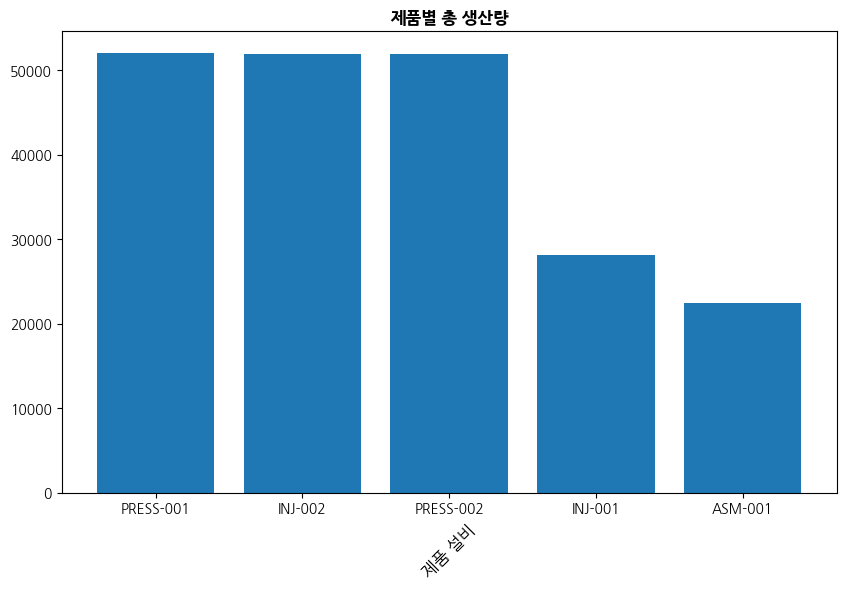

In [23]:
plt.bar(data1.index,data1,)
plt.title('제품별 총 생산량',fontweight='bold')
plt.xlabel('제품 설비',fontsize= 12, rotation =45) # 라벨 작성
plt.show()

In [ ]:
# 여기에 코드 작성


---
## 문제 2: 일별 불량률 추이 선 그래프 (15점)

**요구사항**:
1. 일별 평균 불량률 집계 (처음 30일)
2. 제목: '일별 평균 불량률 추이 (30일)'
3. x축 레이블 45도 회전

**힌트**: `groupby()`, `head(30)`

In [18]:
# 여기에 코드 작성
data2=production_df.groupby('production_date').agg({'defect_rate':'mean'})

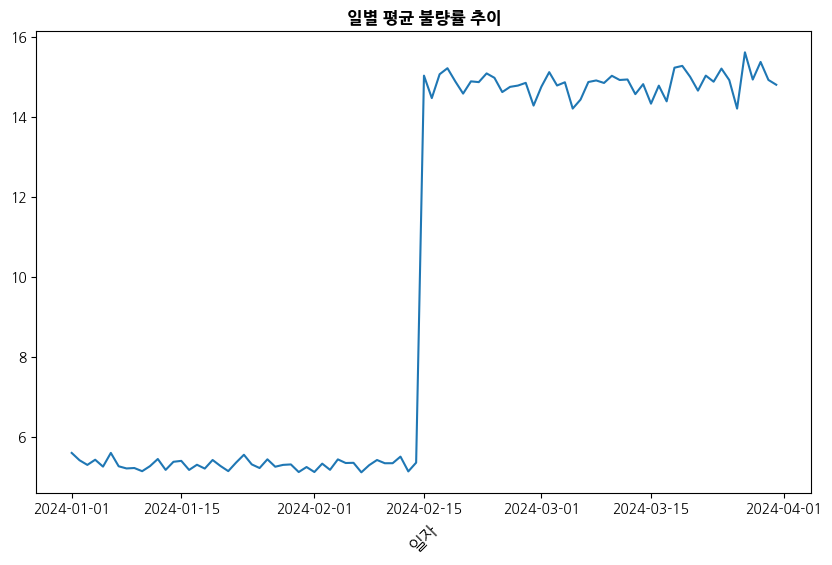

In [ ]:
plt.plot(data2.index,data2)
plt.title('일별 평균 불량률 추이(30일)',fontweight='bold')
plt.xlabel('일자',fontsize= 12, rotation =45) # 라벨 작성
plt.show()

---
## 문제 3: 설비별 평균 사이클 타임 가로 bar 그래프 (10점)

**요구사항**:
1. 설비별 평균 사이클 타임 집계
2. 사이클 타임 내림차순 정렬 (상위 10개)
3. 가로 그래프 생성
4. 제목: '설비별 평균 사이클 타임 (상위 10개)'
5. x축 격자 추가



In [28]:
data3=production_df.groupby('equipment_id')['cycle_time'].mean().sort_values(ascending=False)

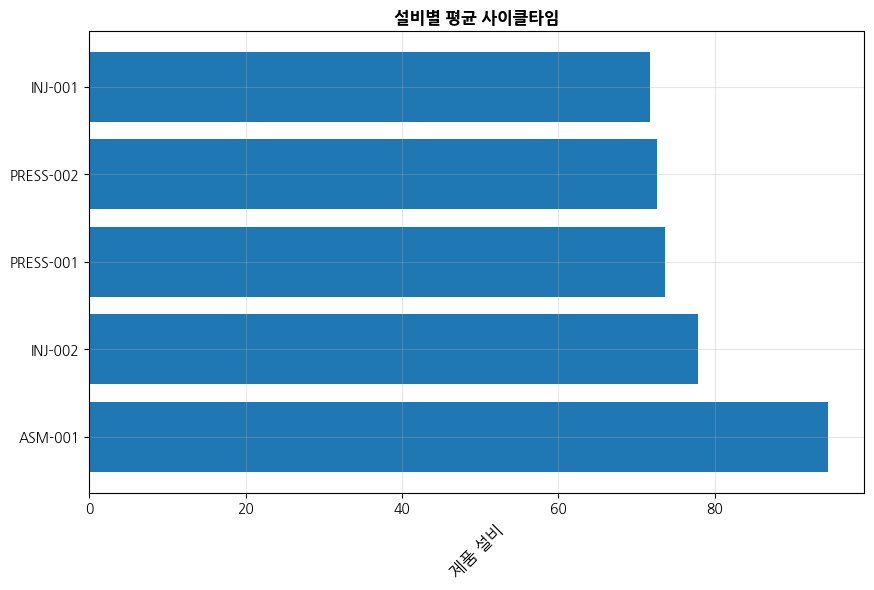

In [30]:
plt.barh(data3.index,data3)
plt.title('설비별 평균 사이클타임',fontweight='bold')
plt.xlabel('제품 설비',fontsize= 12, rotation =45) # 라벨 작성
plt.grid(True,alpha=0.3) # 격자
plt.show()

---
## 문제 4: 사이클 타임 분포 그리기 (15점)

**요구사항**:
1. 사이클 타임 (bins=40)
2. 막대 색상: 'lightgreen', 테두리: 'black'
3. 평균값을 빨간 점선으로 표시 (linewidth=2)
4. 중앙값을 파란 점선으로 표시 (linewidth=2)
5. 제목: '사이클 타임 분포'
6. 범례 추가 (평균: XX초, 중앙값: XX초)
7. y축 격자 추가

**힌트**: `plt.axvline()`

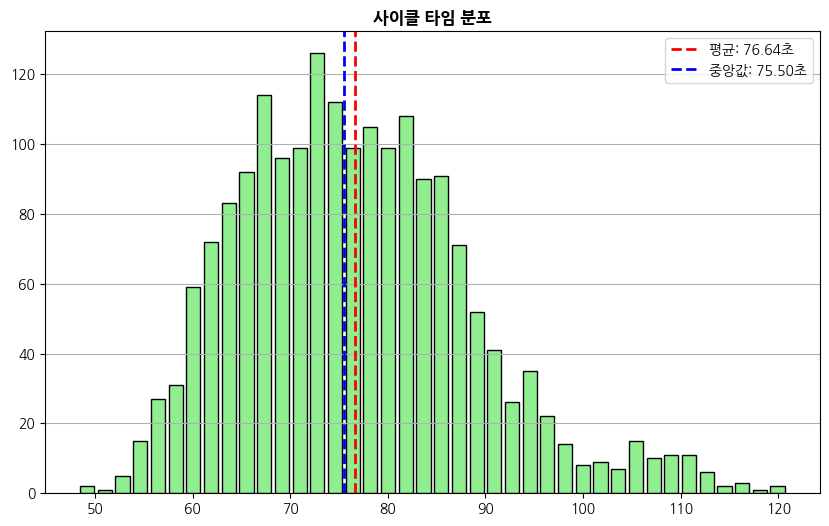

In [38]:

cycle_time = production_df['cycle_time']

# 평균, 중앙값 계산
mean_val = np.mean(cycle_time)
median_val = np.median(cycle_time)

# 히스토그램
plt.hist(cycle_time,
         bins=40,
         rwidth=0.8,
         color='lightgreen',
         edgecolor='black')

# 평균선
plt.axvline(mean_val,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'평균: {mean_val:.2f}초')

# 중앙값선
plt.axvline(median_val,
            color='blue',
            linestyle='--',
            linewidth=2,
            label=f'중앙값: {median_val:.2f}초')

# 제목
plt.title('사이클 타임 분포', fontweight='bold')

# 범례
plt.legend()

# y축 격자
plt.grid(axis='y')

plt.show()



---
## 문제 5: 생산량 vs 사이클 타임 차트 (15점)

**요구사항**:
1. 실제 생산량(x축) vs 사이클 타임(y축) 
2. 교대조별로 색상 구분 (for loop 사용)
3. 제목: '생산량 vs 사이클 타임 (교대조별)'
4. 범례 추가

**힌트**: `for shift in df['shift'].unique()`

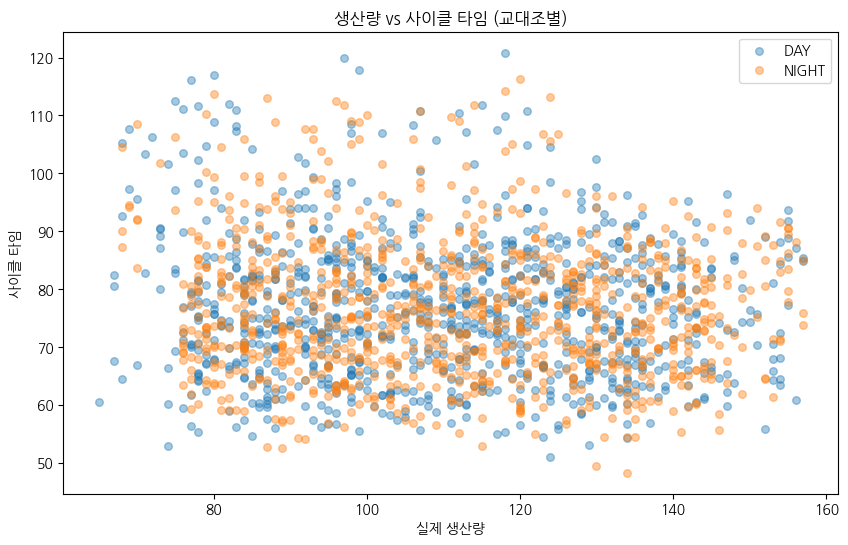

In [40]:



# 교대조별 산점도
for shift in production_df['shift'].unique():
    
    shift_data = production_df[production_df['shift'] == shift]
    
    plt.scatter(shift_data['actual_quantity'],
                shift_data['cycle_time'],
                s=30,
                alpha=0.4,
                label=shift)

# 제목
plt.title('생산량 vs 사이클 타임 (교대조별)')

# x, y축 라벨 (문제에 명시는 없지만 보통 감점 방지용으로 넣는 게 안전)
plt.xlabel('실제 생산량')
plt.ylabel('사이클 타임')

# 범례
plt.legend()

plt.show()


---
## 문제 6: 제품별 생산 비율 차트 (10점)

**요구사항**:
1. 제품별 생산 건수 집계
2. 차트 생성 : 퍼센트 표시 
3. 제목: '제품별 생산 건수 비율'
4. Figure 크기: (8, 8)



In [ ]:
# 여기에 코드 작성
data1

equipment_id
PRESS-001    52069
INJ-002      51958
PRESS-002    51929
INJ-001      28163
ASM-001      22485
Name: actual_quantity, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

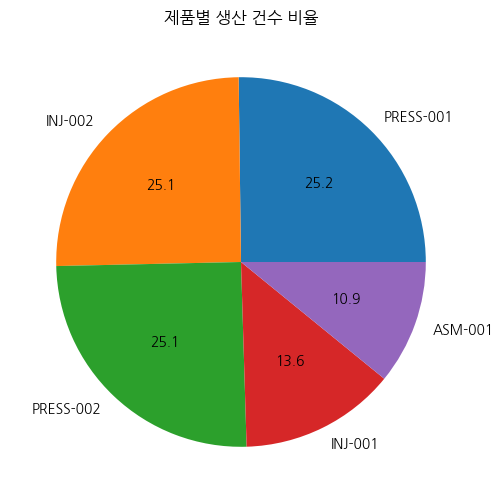

In [45]:
plt.Figure(figsize=(8,8))
plt.pie(data1,labels=data1.index,autopct='%.1f')
plt.title('제품별 생산 건수 비율')
plt.show

---
## 문제 7: 교대조별 일별 생산량 비교 선 그래프 (15점)

**요구사항**:
1. 교대조-날짜별 총 생산량 집계 (처음 30일)
2. 주간조와 야간조를 각각 다른 선으로 표시:
   - 주간조: 파란색, 마커 'o'
   - 야간조: 주황색, 마커 's'
3. 선 굵기: 2, 마커 크기: 4
4. 제목: '교대조별 일별 생산량 비교 (30일)'
5. 범례 추가
6. 격자 추가
7. x축 레이블 45도 회전



In [46]:
production_df.head(2)

,production_id,equipment_id,product_code,production_date,start_time,end_time,target_quantity,actual_quantity,good_quantity,defect_quantity,cycle_time,work_order_no,lot_no,operator_id,shift,created_at,updated_at,defect_rate
0,1,INJ-001,BUMPER-A,2024-01-01,2024-01-01 08:14:00,2024-01-01 09:53:32,97,81,77,4,73.73,WO202401019935,LOT2024010100101,OP003,DAY,2026-01-30 00:42:48,2026-01-30 00:42:48,4.94
1,2,INJ-001,BUMPER-A,2024-01-01,2024-01-01 21:02:00,2024-01-01 22:33:43,83,78,72,6,70.56,WO202401012535,LOT2024010100110,OP006,NIGHT,2026-01-30 00:42:48,2026-01-30 00:42:48,7.69


In [69]:
data4=production_df.groupby(['shift','production_date']).agg({'actual_quantity':'sum'})

In [71]:
data4 = data4.reset_index()

In [78]:
data4_day=data4[data4['shift']=='DAY'].copy()

In [79]:
data4_night=data4[data4['shift']=='NIGHT'].copy()

Text(0, 0.5, '생산량')

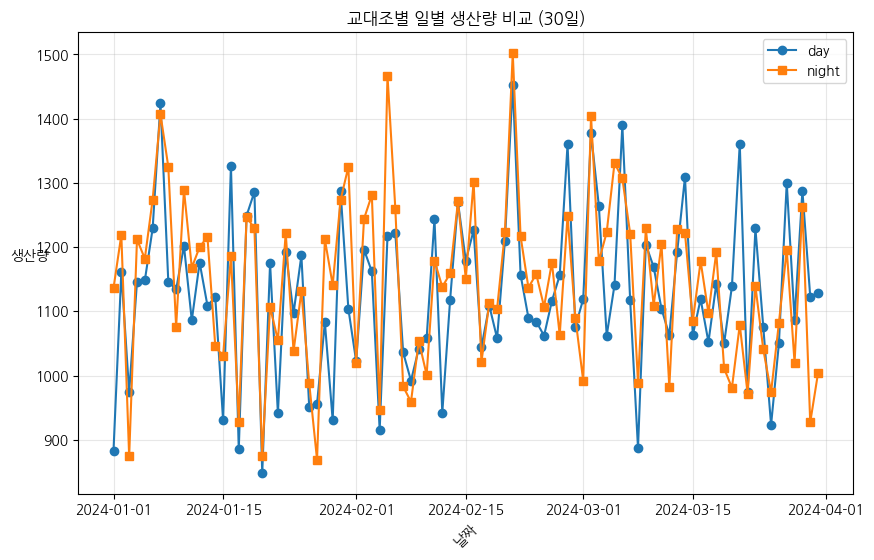

In [101]:
plt.plot(data4_day['production_date'],data4_day['actual_quantity'],marker='o',label='day')
plt.plot(data4_night['production_date'],data4_night['actual_quantity'],marker='s',label='night')
plt.title('교대조별 일별 생산량 비교 (30일)')
plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('날짜',rotation=45)
plt.ylabel('생산량',rotation=0)


---
## 문제 8: 설비 생산 현황 2x1 subplot (20점)

**요구사항**:
설비별 생산 현황을 2개의 subplot으로 구성:

1. **상단 [0]**: 설비별 총 생산량 막대 그래프 (상위 10개)
   - 막대 색상: 'steelblue', 테두리: 'black'
   - 제목: '설비별 총 생산량'
   - x축 레이블 45도 회전
   - y축 격자

2. **하단 [1]**: 설비별 평균 불량률 막대 그래프 (상위 10개)
   - 막대 색상: 'coral', 테두리: 'black'
   - 제목: '설비별 평균 불량률'
   - x축 레이블 45도 회전
   - y축 격자

3. Figure 크기: (12, 10)
4. `plt.tight_layout()` 적용

**힌트**: `fig, axes = plt.subplots(2, 1)`, `axes[0]`, `axes[1]`

In [103]:
# 여기에 코드 작성
df_9=production_df.groupby('equipment_id')['actual_quantity'].sum()


In [111]:
df_10=production_df.groupby('equipment_id')['defect_rate'].mean()

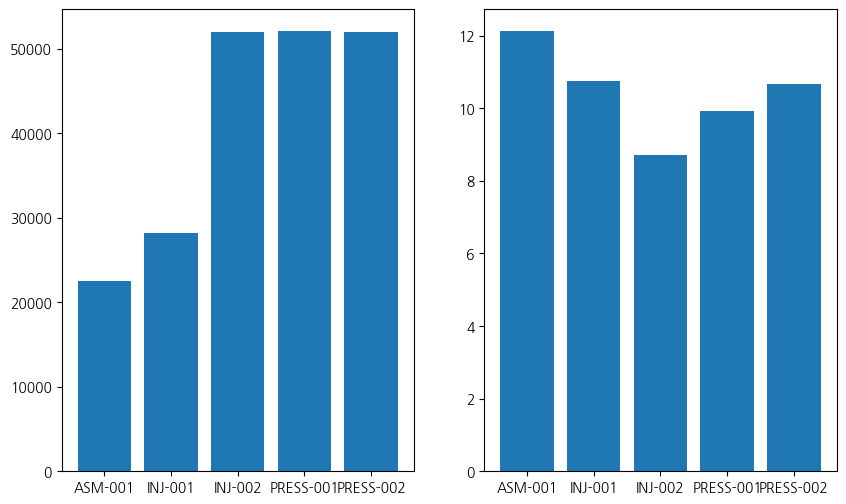

In [112]:
## 두개의 그래프 한번에 드리는 법


plt.subplot(1,2,1)
plt.bar(df_9.index,df_9.values)
plt.subplot(1,2,2)
plt.bar(df_10.index,df_10.values)

plt.show()

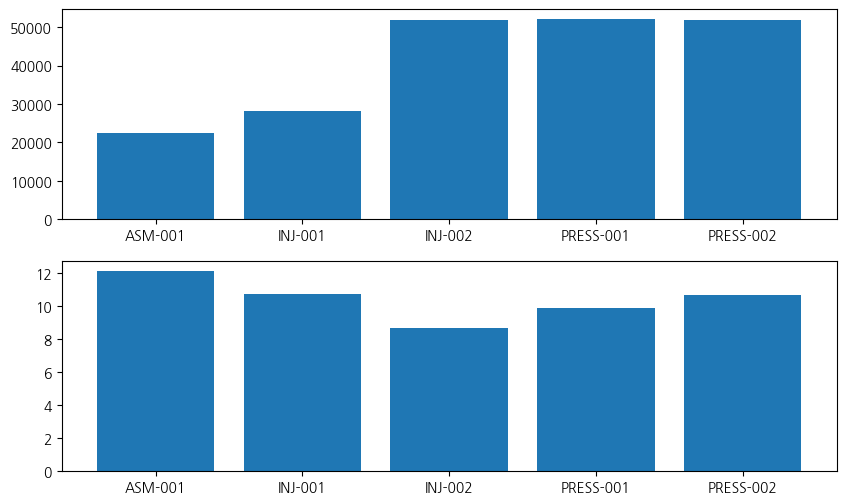

In [117]:
## 두개의 그래프 한번에 드리는 법


plt.subplot(2,1,1)
plt.bar(df_9.index,df_9.values)
plt.subplot(2,1,2)
plt.bar(df_10.index,df_10.values)

plt.show()

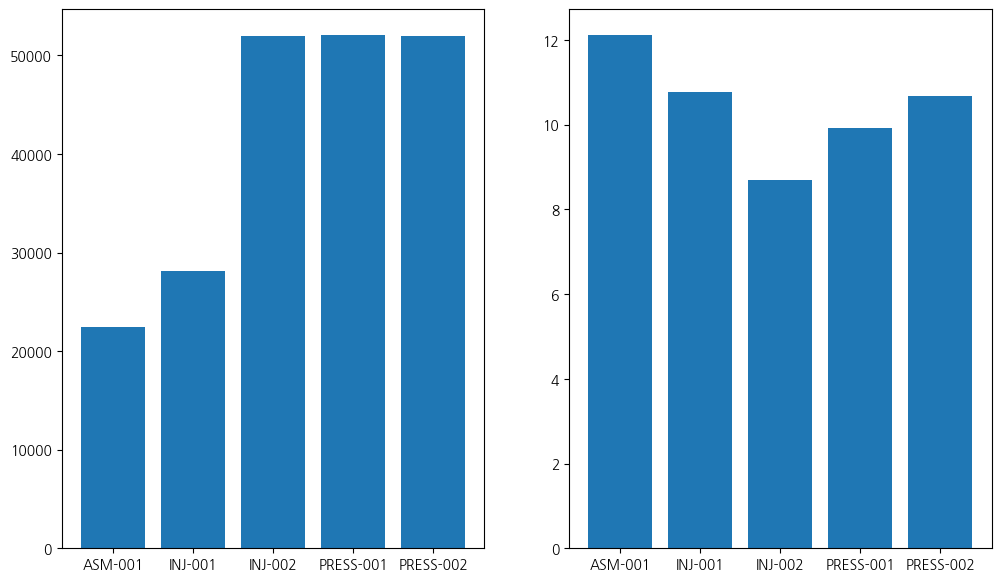

In [131]:
fig, axes =plt.subplots(1,2,figsize=(12,7))

axes[0].bar(df_9.index,df_9.values)

axes[1].bar(df_10.index,df_10.values)

plt.show()

---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 선 그래프 그리기 및 스타일링
- [ ] 막대 그래프 (세로/가로)
- [ ] 산점도 및 색상 구분
- [ ] 히스토그램 및 통계선 표시
- [ ] 파이 차트
- [ ] 여러 선 그래프 함께 표시
- [ ] Subplot으로 다중 차트 구성
- [ ] 제목, 레이블, 범례, 격자 추가
